In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [10]:
def weighted_bootstrap(data, func=np.mean, weights=None, n_resamples=1000, rng=None):
    '''
    from ursa
    '''

    # Create a default random number generator if none is provided
    rng = np.random.default_rng() if rng is None else rng

    # If no weights are provided, use equal weights
    if weights is None:
        weights = np.ones(len(data))

    # Generate bootstrap samples by randomly selecting elements with replacement,
    # using the provided weights as sampling probabilities
    bootstrap_samples = rng.choice(
        data,
        size=(n_resamples, len(data)),
        replace=True,
        p=weights / np.sum(weights),  # Normalize weights to sum to 1
        axis=0
    )

    # Apply the statistic function to each resample along the axis of resampling
    statistic = func(bootstrap_samples, axis=1)

    # Compute the 95% confidence interval (2.5th and 97.5th percentiles)
    ci = np.percentile(statistic, [2.5, 97.5], axis=0)

    return np.mean(statistic, axis=0), ci

In [8]:
# loading multiple files with different time intervals
files = [
    # '/Volumes/cytokinesis-zebrafish/Processed data/band_length/1_SNT_measurements/20210625_CSV_Properties_10x_to66.csv',
    './20250703_CSV_Properties_10x1.csv',
    './20250703_CSV_Properties_10x2.csv',
    './20250703_CSV_Properties_10x3_embryo1.csv',
    './20250703_CSV_Properties_10x3_embryo2.csv'
]
intervals = [60,60,60,60]
# multi_factor = [2,2,2,2]
M_phase_sync = [14,17,16,15] # in minutes, synchronise slice data

df_all_data = pd.DataFrame()
for (i, file) in enumerate(files):
    df = pd.read_csv(file)
    df['file'] = file.replace('./', '')
    df['time'] = df['PathID'] - M_phase_sync[i] + min(M_phase_sync) -1
    df_all_data = pd.concat([df_all_data, df], ignore_index=True)

df_all_data.head()

,PathID,PathName,SWCType,PrimaryPath,PathLength,PathLengthUnits,StartsOnPath,ConnectedPathIDs,ChildPathIDs,StartX,StartY,StartZ,EndX,EndY,EndZ,ApproximateFittedVolume,file,time
0,1,Path (1),undefined,True,77.657382,µm,NaN,NaN,NaN,417.095067,358.785057,223.72,451.010072,289.170046,220.15,NaN,20250703_CSV_Properties_10x1.csv,0
1,2,Path (2),undefined,True,86.116965,µm,NaN,NaN,NaN,414.715066,358.785057,223.72,453.390073,282.030045,220.15,NaN,20250703_CSV_Properties_10x1.csv,1
2,3,Path (3),undefined,True,112.064356,µm,NaN,NaN,NaN,414.715066,358.785057,221.34,464.100074,258.230041,220.15,NaN,20250703_CSV_Properties_10x1.csv,2
3,4,Path (4),undefined,True,142.766767,µm,NaN,NaN,NaN,412.335066,358.785057,220.15,474.810076,230.860037,218.96,NaN,20250703_CSV_Properties_10x1.csv,3
4,5,Path (5),undefined,True,139.876170,µm,NaN,NaN,NaN,413.525066,359.975058,218.96,479.570077,236.810038,217.77,NaN,20250703_CSV_Properties_10x1.csv,4


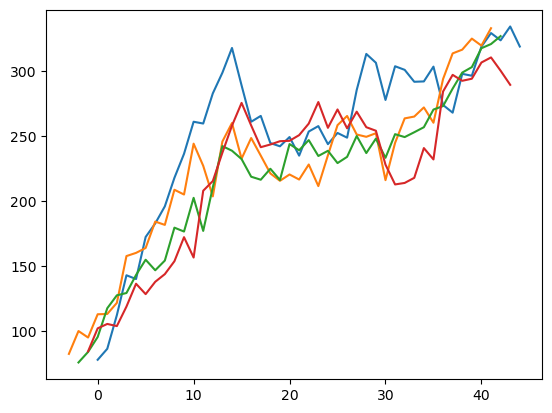

In [9]:
for file in df_all_data['file'].unique():
    plt.plot(df_all_data.loc[df_all_data['file']==file, 'time'], df_all_data.loc[df_all_data['file']==file, 'PathLength'])

plt.show()

In [21]:
data = np.array([df_all_data.loc[(df_all_data['file']==file)&(df_all_data['time']>=0)&(df_all_data['time']<=40), 'PathLength'].values for file in df_all_data['file'].unique()])
data_time = np.linspace(0, 40, 41)
average, ci = weighted_bootstrap(data)

print(average, ci)

[ 96.70657984 105.21782504 115.99137191 136.94792199 144.67114388
 154.74822654 162.83290387 168.89780703 189.90755442 197.69565
 216.05209582 218.28044253 228.53100145 256.34101392 269.12645947
 257.84675654 246.85663039 239.8765967  233.74081333 230.22800025
 240.12221745 235.43401419 247.19654411 245.3795813  243.60804224
 252.78024585 251.0954422  264.16970905 264.5952117  265.57033068
 239.11855843 253.4321708  257.09821368 257.0020205  265.54902396
 266.68800211 281.29295066 291.1845958  301.41947922 304.5766068
 315.72780542] [[ 83.71102131  92.82335741 105.73237615 123.86993131 137.14908449
  137.12553773 142.18370744 148.86493368 166.51353173 174.28663335
  178.36295467 189.48404214 206.47893481 239.36458426 244.06081014
  232.44869522 228.57469281 222.64936599 223.03469953 215.86012431
  226.91694557 222.17483711 234.45885157 223.03037749 236.94229108
  236.50828489 239.50304219 250.64683206 241.90375201 249.57016033
  220.36053773 222.43402473 226.33745112 229.64509735 248.5

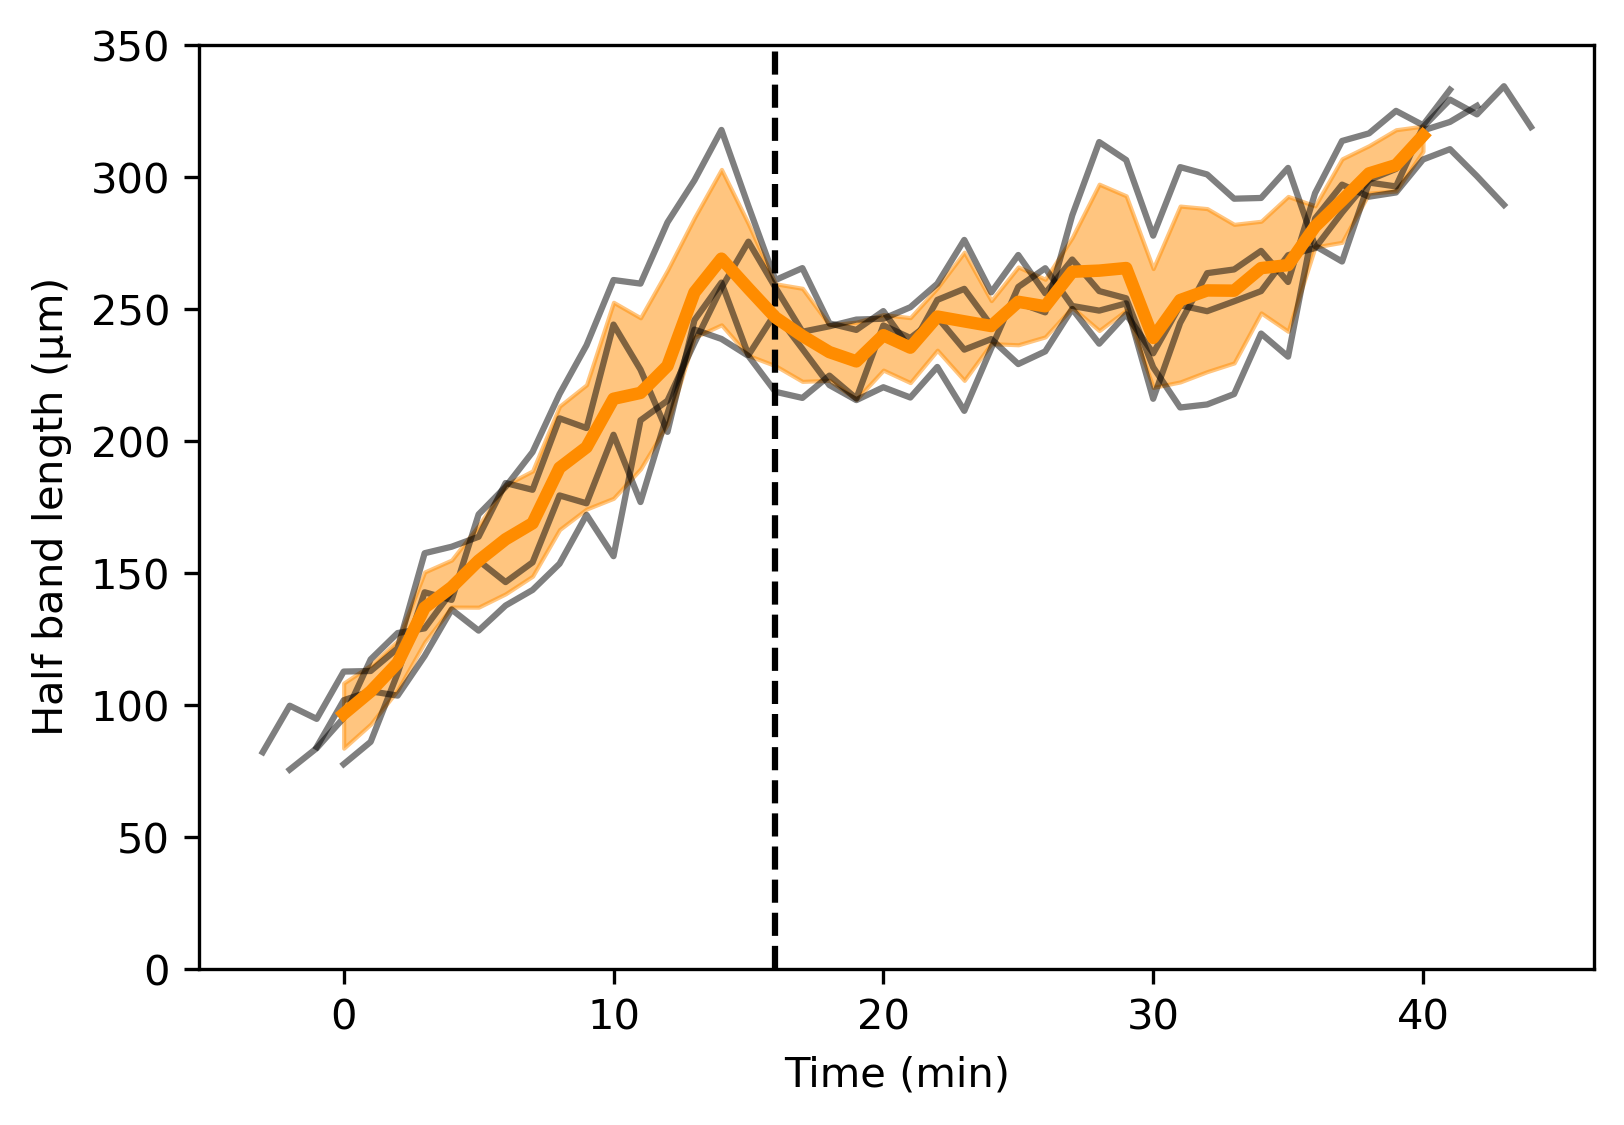

In [40]:
plt.figure(figsize=(6, 4), dpi=300)
for file in df_all_data['file'].unique():
    plt.plot(df_all_data.loc[df_all_data['file']==file, 'time'], df_all_data.loc[df_all_data['file']==file, 'PathLength'], 'k', alpha =0.5)

plt.vlines(16, 0, 350, 'k', linestyles='--')
plt.plot(data_time, average, color = 'darkorange', linewidth=3)
plt.fill_between(data_time, ci[0], ci[1], color='darkorange', alpha =0.5)
plt.ylim(0, 350)
plt.xlabel('Time (min)')
plt.ylabel('Half band length ($\\mathrm{\\mu}$m)')

plt.savefig('/Volumes/cytokinesis-zebrafish-collab/4Alison/half_band_length_bootstrapped.svg', format='svg')
plt.show()